In [30]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch import Tensor
import torch.optim as optim
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import negative_sampling
from torch_geometric.nn.conv.gcn_conv import gcn_norm
import networkx as nx
from itertools import combinations
from tqdm.auto import tqdm
import re
import warnings
warnings.filterwarnings('ignore')

In [31]:
import zipfile
import os

zip_path = r"C:\Users\Simone\OneDrive\Desktop\emails.csv.zip"
extract_path = r"C:\Users\Simone\enron"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print(os.listdir(extract_path))

['emails.csv']


In [32]:
df = pd.read_csv(r"C:\Users\Simone\enron\emails.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst row:\n", df.iloc[0])

Shape: (517401, 2)

Columns: ['file', 'message']

First row:
 file                                   allen-p/_sent_mail/1.
message    Message-ID: <18782981.1075855378110.JavaMail.e...
Name: 0, dtype: object


In [33]:
df = pd.read_csv(r"C:\Users\Simone\enron\emails.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nNull counts:\n", df.isnull().sum())
print("\nSample row:\n", df.iloc[0])
print("\nFirst 5 rows:\n", df.head())

Shape: (517401, 2)

Columns: ['file', 'message']

Dtypes:
 file       object
message    object
dtype: object

Null counts:
 file       0
message    0
dtype: int64

Sample row:
 file                                   allen-p/_sent_mail/1.
message    Message-ID: <18782981.1075855378110.JavaMail.e...
Name: 0, dtype: object

First 5 rows:
                        file                                            message
0     allen-p/_sent_mail/1.  Message-ID: <18782981.1075855378110.JavaMail.e...
1    allen-p/_sent_mail/10.  Message-ID: <15464986.1075855378456.JavaMail.e...
2   allen-p/_sent_mail/100.  Message-ID: <24216240.1075855687451.JavaMail.e...
3  allen-p/_sent_mail/1000.  Message-ID: <13505866.1075863688222.JavaMail.e...
4  allen-p/_sent_mail/1001.  Message-ID: <30922949.1075863688243.JavaMail.e...


In [34]:
def parse_field(message, field):
    match = re.search(rf'^{field}:\s*(.+)', message, re.MULTILINE)
    return match.group(1).strip() if match else None

df['from'] = df['message'].apply(lambda x: parse_field(x, 'From'))
df['to']   = df['message'].apply(lambda x: parse_field(x, 'To'))
df['date'] = df['message'].apply(lambda x: parse_field(x, 'Date'))
df['subject'] = df['message'].apply(lambda x: parse_field(x, 'Subject'))

print(df[['from','to','date','subject']].head(10))
print("\nNull from:", df['from'].isnull().sum())
print("Null to:  ", df['to'].isnull().sum())

                      from                                                to  \
0  phillip.allen@enron.com                              tim.belden@enron.com   
1  phillip.allen@enron.com                           john.lavorato@enron.com   
2  phillip.allen@enron.com                            leah.arsdall@enron.com   
3  phillip.allen@enron.com                             randall.gay@enron.com   
4  phillip.allen@enron.com                              greg.piper@enron.com   
5  phillip.allen@enron.com                              greg.piper@enron.com   
6  phillip.allen@enron.com  david.l.johnson@enron.com, john.shafer@enron.com   
7  phillip.allen@enron.com                          joyce.teixeira@enron.com   
8  phillip.allen@enron.com                              mark.scott@enron.com   
9  phillip.allen@enron.com                                   zimam@enron.com   

                                    date  \
0  Mon, 14 May 2001 16:39:00 -0700 (PDT)   
1   Fri, 4 May 2001 13:51:00 -0

In [35]:
def clean_email(addr):
    if not isinstance(addr, str):
        return None
    addr = addr.strip().lower()
    addr = re.sub(r'\s+', '', addr)
    if '@' not in addr:
        return None
    return addr

df = df.dropna(subset=['from', 'to'])

df['from'] = df['from'].apply(clean_email)

df['to'] = df['to'].apply(lambda x: [
    clean_email(e) for e in re.split(r'[,;]', x)
    if clean_email(e) is not None
])

df = df[df['from'].notna()]
df = df[df['to'].map(len) > 0]

df_exploded = df.explode('to').reset_index(drop=True)
df_exploded = df_exploded[df_exploded['from'] != df_exploded['to']]
df_exploded = df_exploded.dropna(subset=['from', 'to'])

print("Total edges (raw):", len(df_exploded))
print("Unique senders:  ", df_exploded['from'].nunique())
print("Unique receivers:", df_exploded['to'].nunique())
print(df_exploded[['from','to']].head(10))

Total edges (raw): 713665
Unique senders:   19447
Unique receivers: 26063
                      from                         to
0  phillip.allen@enron.com       tim.belden@enron.com
1  phillip.allen@enron.com    john.lavorato@enron.com
2  phillip.allen@enron.com     leah.arsdall@enron.com
3  phillip.allen@enron.com      randall.gay@enron.com
4  phillip.allen@enron.com       greg.piper@enron.com
5  phillip.allen@enron.com       greg.piper@enron.com
6  phillip.allen@enron.com  david.l.johnson@enron.com
7  phillip.allen@enron.com      john.shafer@enron.com
8  phillip.allen@enron.com   joyce.teixeira@enron.com
9  phillip.allen@enron.com       mark.scott@enron.com


In [36]:
edge_counts = df_exploded.groupby(['from','to']).size().reset_index(name='weight')
edge_counts = edge_counts[edge_counts['weight'] >= 1]

all_users = pd.unique(edge_counts[['from','to']].values.ravel())
user2idx  = {u: i for i, u in enumerate(all_users)}
idx2user  = {i: u for u, i in user2idx.items()}
num_users = len(all_users)

print("Unique users in graph:", num_users)
print("Edges after weight filter:", len(edge_counts))
print(edge_counts.head())

src = torch.tensor([user2idx[u] for u in edge_counts['from']], dtype=torch.long)
dst = torch.tensor([user2idx[u] for u in edge_counts['to']],   dtype=torch.long)

edge_index = torch.stack([
    torch.cat([src, dst]),
    torch.cat([dst, src])
], dim=0)

print("\nedge_index shape:", edge_index.shape)

Unique users in graph: 36613
Edges after weight filter: 104339
                             from                      to  weight
0   'todd'.delahoussaye@enron.com  derek.bailey@enron.com       5
1   'todd'.delahoussaye@enron.com     jean.bell@enron.com       5
2   'todd'.delahoussaye@enron.com  randy.bhatia@enron.com       5
3   'todd'.delahoussaye@enron.com  susan.bailey@enron.com       1
4  --migrated--bmishkin@ercot.com    mockmarket@ercot.com       1

edge_index shape: torch.Size([2, 208678])


In [37]:
num_edges = edge_index.shape[1] // 2
perm = torch.randperm(num_edges)

train_end = int(0.8 * num_edges)
val_end   = int(0.9 * num_edges)

train_idx = perm[:train_end]
val_idx   = perm[train_end:val_end]
test_idx  = perm[val_end:]

def make_bidirectional(idx):
    s = torch.cat([src[idx], dst[idx]])
    d = torch.cat([dst[idx], src[idx]])
    return torch.stack([s, d])

train_edge_index = make_bidirectional(train_idx)
val_edge_index   = make_bidirectional(val_idx)
test_edge_index  = make_bidirectional(test_idx)

print("Train edges:", train_edge_index.shape)
print("Val edges:  ", val_edge_index.shape)
print("Test edges: ", test_edge_index.shape)

Train edges: torch.Size([2, 166942])
Val edges:   torch.Size([2, 20868])
Test edges:  torch.Size([2, 20868])


In [38]:
class FriendGNN(MessagePassing):
    def __init__(self, num_users, embedding_dim=64, K=3, add_self_loops=False):
        super().__init__()
        self.num_users      = num_users
        self.embedding_dim  = embedding_dim
        self.K              = K
        self.add_self_loops = add_self_loops

        self.emb = nn.Embedding(num_users, embedding_dim)
        nn.init.normal_(self.emb.weight, std=0.1)

    def forward(self, edge_index: Tensor):
        edge_index_norm = gcn_norm(
            edge_index,
            num_nodes=self.num_users,
            add_self_loops=self.add_self_loops
        )
        emb_0 = self.emb.weight
        embs  = [emb_0]
        emb_k = emb_0

        for _ in range(self.K):
            emb_k = self.propagate(
                edge_index=edge_index_norm[0],
                x=emb_k,
                norm=edge_index_norm[1]
            )
            embs.append(emb_k)

        emb_final = torch.mean(torch.stack(embs, dim=1), dim=1)
        return emb_final, emb_0

    def message(self, x_j, norm):
        return norm.view(-1, 1) * x_j

In [39]:
def bpr_loss(emb_final, emb_0, pos_src, pos_dst, neg_dst, lambda_val=1e-4):
    u   = emb_final[pos_src]
    pos = emb_final[pos_dst]
    neg = emb_final[neg_dst]

    pos_scores = (u * pos).sum(dim=-1)
    neg_scores = (u * neg).sum(dim=-1)

    bpr  = -torch.mean(torch.nn.functional.softplus(pos_scores - neg_scores))
    reg  = lambda_val * (
        emb_0[pos_src].norm(2).pow(2) +
        emb_0[pos_dst].norm(2).pow(2) +
        emb_0[neg_dst].norm(2).pow(2)
    )
    return bpr + reg

In [41]:
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ITERATIONS = 25000
LR         = 1e-3
LAMBDA     = 1e-4
BATCH_SIZE = 1024
ITERS_PER_EVAL = 500

model     = FriendGNN(num_users=num_users).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

train_ei = train_edge_index.to(device)
train_losses = []

for iter in tqdm(range(ITERATIONS), mininterval=1.0):
    model.train()
    emb_final, emb_0 = model.forward(train_ei)

    idx     = torch.randint(0, train_ei.shape[1] // 2, (BATCH_SIZE,))
    pos_src = train_ei[0][idx]
    pos_dst = train_ei[1][idx]
    neg_dst = torch.randint(0, num_users, (BATCH_SIZE,), device=device)

    loss = bpr_loss(emb_final, emb_0, pos_src, pos_dst, neg_dst, LAMBDA)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if iter % ITERS_PER_EVAL == 0:
        print(f"[{iter}/{ITERATIONS}] loss: {round(loss.item(), 5)}")

    if iter % 2000 == 0 and iter != 0:
        scheduler.step()

  0%|                                                                                        | 0/25000 [00:00<?, ?it/s]

[0/25000] loss: -0.50543


  2%|█▌                                                                          | 498/25000 [01:45<1:23:34,  4.89it/s]

[500/25000] loss: -39.26321


  4%|███                                                                        | 1001/25000 [03:27<1:20:35,  4.96it/s]

...

 96%|███████████████████████████████████████████████████████████████████████   | 23998/25000 [1:15:10<03:23,  4.92it/s]

[24000/25000] loss: -32867.60156


 98%|████████████████████████████████████████████████████████████████████████▌ | 24499/25000 [1:16:49<01:34,  5.29it/s]

[24500/25000] loss: -31447.875


100%|██████████████████████████████████████████████████████████████████████████| 25000/25000 [1:18:29<00:00,  5.31it/s]


In [42]:
model.eval()
with torch.no_grad():
    emb_final, _ = model.forward(train_ei)

def recommend_friends(user_email, top_k=10):
    if user_email not in user2idx:
        print("User not found.")
        return

    uid = user2idx[user_email]

    existing = set(
        edge_index[1][edge_index[0] == uid].tolist()
    )
    existing.add(uid)

    scores = (emb_final[uid] * emb_final).sum(dim=-1)
    scores[list(existing)] = -1e9

    top_scores, top_ids = torch.topk(scores, top_k)
    top_scores = torch.sigmoid(top_scores)

    print(f"\nTop {top_k} recommendations for: {user_email}\n")
    print(f"{'User':<40} {'Score':>8}")
    print("-" * 50)
    for idx, score in zip(top_ids.tolist(), top_scores.tolist()):
        print(f"{idx2user[idx]:<40} {score:>8.4f}")

recommend_friends(idx2user[0])


Top 10 recommendations for: 'todd'.delahoussaye@enron.com

User                                        Score
--------------------------------------------------
sara.shackleton@enron.com                  1.0000
tana.jones@enron.com                       1.0000
vince.kaminski@enron.com                   1.0000
jeff.dasovich@enron.com                    1.0000
jeff.skilling@enron.com                    1.0000
gerald.nemec@enron.com                     1.0000
kenneth.lay@enron.com                      1.0000
mark.taylor@enron.com                      1.0000
kay.mann@enron.com                         1.0000
sally.beck@enron.com                       1.0000


In [43]:
recommend_friends('phillip.allen@enron.com')


Top 10 recommendations for: phillip.allen@enron.com

User                                        Score
--------------------------------------------------
sara.shackleton@enron.com                  1.0000
tana.jones@enron.com                       1.0000
vince.kaminski@enron.com                   1.0000
jeff.skilling@enron.com                    1.0000
gerald.nemec@enron.com                     1.0000
kenneth.lay@enron.com                      1.0000
kay.mann@enron.com                         1.0000
debra.perlingiere@enron.com                1.0000
chris.germany@enron.com                    1.0000
louise.kitchen@enron.com                   1.0000


In [44]:
import networkx as nx
from itertools import combinations

G = nx.Graph()
edges_list = list(zip(src.tolist(), dst.tolist()))
G.add_edges_from(edges_list)

def get_clique_suggestions(user_email, top_k=10):
    if user_email not in user2idx:
        print("User not found.")
        return

    uid = user2idx[user_email]

    components = [c for c in nx.connected_components(G) if uid in c]
    if not components:
        print("User has no connections.")
        return

    component = G.subgraph(components[0])
    cliques   = list(nx.find_cliques(component))
    user_cliques = [c for c in cliques if uid in c]

    print(f"\nUser: {user_email}")
    print(f"Is in {len(user_cliques)} clique(s)\n")

    # Part 1: General connection suggestions based on mutual neighbors
    non_edges = []
    for node in component.nodes():
        if node != uid and not G.has_edge(uid, node):
            mutual = len(list(nx.common_neighbors(G, uid, node)))
            score  = mutual / (G.degree(uid) + G.degree(node) - mutual + 1e-9)
            non_edges.append((node, mutual, round(score, 4)))

    non_edges.sort(key=lambda x: x[2], reverse=True)

    print(f"Top {top_k} users to connect with (general recommendations):\n")
    print(f"{'User':<40} {'Mutuals':>8} {'Score':>8}")
    print("-" * 58)
    for node, mutual, score in non_edges[:top_k]:
        print(f"{idx2user[node]:<40} {mutual:>8} {score:>8.4f}")

    # Part 2: Clique Expansion Logic 
    if not user_cliques:
        return

    max_clique = set(max(user_cliques, key=len))
    clique_size = len(max_clique)
    
    candidates = {}
    for node in component.nodes():
        if node not in max_clique:
            # Count how many members of the max_clique this node is connected to
            conn_to_clique = sum(1 for member in max_clique if G.has_edge(node, member))
            if conn_to_clique > 0:
                candidates[node] = conn_to_clique

    sorted_candidates = sorted(candidates.items(), key=lambda x: x[1], reverse=True)

    print(f"\nYour largest clique has {clique_size} members:")
    print(f"[{', '.join([idx2user[n] for n in max_clique])}]")

    print(f"\nTop users who would EXPAND this clique:")
    print(f"{'User':<40} {'Connections':>12} {'Status'}")
    print("-" * 65)
    
    for node, conn in sorted_candidates[:top_k]:
        status = "Ready to join" if conn == clique_size else f" Needs {clique_size - conn} more edges"
        print(f"{idx2user[node]:<40} {conn:>5}/{clique_size}      {status}")

get_clique_suggestions(idx2user[0])


User: 'todd'.delahoussaye@enron.com
Is in 4 clique(s)

Top 10 users to connect with (general recommendations):

User                                      Mutuals    Score
----------------------------------------------------------
julie.brewer@enron.com                          2   0.2500
admin@iwin.com                                  1   0.2000
brooksbrothers@clickaction.net                  1   0.2000
cptdougie@aol.com                               1   0.2000
dona.carmony@ourclub.com                        1   0.2000
dsciullo@bw-legal.com                           1   0.2000
emailconfirm@180096hotel.com                    1   0.2000
bottomlineusa@hotmail.com                       1   0.2000
bsrevada@yahoo.com                              1   0.2000
cheryl.luster@enron.com                         1   0.2000

Your largest clique has 3 members:
['todd'.delahoussaye@enron.com, derek.bailey@enron.com, errol.mclaughlin@enron.com]

Top users who would EXPAND this clique:
User              

In [45]:
recommend_friends('phillip.allen@enron.com')
get_clique_suggestions('phillip.allen@enron.com')


Top 10 recommendations for: phillip.allen@enron.com

User                                        Score
--------------------------------------------------
sara.shackleton@enron.com                  1.0000
tana.jones@enron.com                       1.0000
vince.kaminski@enron.com                   1.0000
jeff.skilling@enron.com                    1.0000
gerald.nemec@enron.com                     1.0000
kenneth.lay@enron.com                      1.0000
kay.mann@enron.com                         1.0000
debra.perlingiere@enron.com                1.0000
chris.germany@enron.com                    1.0000
louise.kitchen@enron.com                   1.0000

User: phillip.allen@enron.com
Is in 538 clique(s)

Top 10 users to connect with (general recommendations):

User                                      Mutuals    Score
----------------------------------------------------------
k..allen@enron.com                             50   0.1420
s..shively@enron.com                           26   0.0732


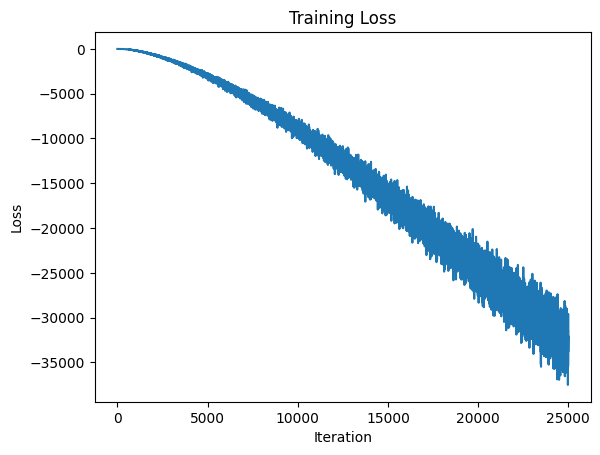

In [46]:
import matplotlib.pyplot as plt
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [47]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse import csgraph
from sklearn.cluster import KMeans

In [48]:
# G already exists from your notebook
N = G.number_of_nodes()
A = nx.to_scipy_sparse_array(G, nodelist=range(N), format='csr', dtype=np.float32)
print(f'Adjacency matrix: {A.shape}')

Adjacency matrix: (36613, 36613)


In [49]:
K = 32  # number of spectral dimensions

print('Computing normalized Laplacian...')
L_norm = csgraph.laplacian(A, normed=True)

print(f'Running eigendecomposition (k={K})...')
eigenvalues, eigenvectors = spla.eigsh(L_norm, k=K + 1, which='SM')

# Sort, drop trivial zero eigenvector
sort_idx    = np.argsort(eigenvalues)
eigenvalues  = eigenvalues[sort_idx][1:]         # (K,)
eigenvectors = eigenvectors[:, sort_idx][:, 1:]  # (N, K)

# L2-normalize rows
spectral_emb = eigenvectors / (np.linalg.norm(eigenvectors, axis=1, keepdims=True) + 1e-8)

print(f'Spectral embeddings shape: {spectral_emb.shape}')
print(f'Fiedler value (λ₂): {eigenvalues[0]:.6f}')
print(f'  → closer to 0 = graph splits easily into communities')

Computing normalized Laplacian...
Running eigendecomposition (k=32)...
Spectral embeddings shape: (36613, 32)
Fiedler value (λ₂): -0.000000
  → closer to 0 = graph splits easily into communities


In [50]:
print('Computing eigenvector centrality...')
try:
    eig_cent = nx.eigenvector_centrality_numpy(G, weight='weight')
    eig_cent_arr = np.array([eig_cent.get(i, 0.0) for i in range(N)], dtype=np.float32)
except Exception:
    # fallback: power iteration
    x = np.ones(N, dtype=np.float32) / N
    for _ in range(100):
        x_new = A @ x
        x_new /= (np.linalg.norm(x_new) + 1e-8)
        if np.linalg.norm(x_new - x) < 1e-6:
            break
        x = x_new
    eig_cent_arr = x

# Normalize to [0,1]
eig_cent_arr = (eig_cent_arr - eig_cent_arr.min()) / (eig_cent_arr.max() - eig_cent_arr.min() + 1e-8)

print('Top 5 most central users:')
for i in np.argsort(eig_cent_arr)[::-1][:5]:
    print(f'  {idx2user[i]:40s}  centrality: {eig_cent_arr[i]:.4f}')

Computing eigenvector centrality...
Top 5 most central users:
  louise.kitchen@enron.com                  centrality: 1.0000
  tana.jones@enron.com                      centrality: 0.8349
  sara.shackleton@enron.com                 centrality: 0.7671
  john.lavorato@enron.com                   centrality: 0.7661
  mark.taylor@enron.com                     centrality: 0.7091


In [51]:
degrees   = np.array([G.degree(i, weight='weight') for i in range(N)], dtype=np.float32)
deg_norm  = degrees / (degrees.max() + 1e-8)

clust     = nx.clustering(G)
clust_arr = np.array([clust.get(i, 0.0) for i in range(N)], dtype=np.float32)

extra        = np.stack([eig_cent_arr, deg_norm, clust_arr], axis=1)  # (N, 3)
node_features = np.concatenate([spectral_emb, extra], axis=1)          # (N, K+3)

print(f'Node feature matrix: {node_features.shape}')
print(f'  {K} spectral dims + eigenvector centrality + weighted degree + clustering coeff')

Node feature matrix: (36613, 35)
  32 spectral dims + eigenvector centrality + weighted degree + clustering coeff


In [52]:
from torch_geometric.nn import LGConv

class SpectralFriendGNN(nn.Module):
    def __init__(self, in_channels, hidden=64, n_layers=3):
        super().__init__()
        self.n_layers = n_layers
        self.input_proj = nn.Sequential(
            nn.Linear(in_channels, hidden),
            nn.LayerNorm(hidden),
        )
        self.convs = nn.ModuleList([LGConv() for _ in range(n_layers)])
        # Learned per-layer aggregation weights (better than uniform avg)
        self.layer_weights = nn.Parameter(torch.ones(n_layers + 1) / (n_layers + 1))

    def encode(self, x, edge_index):
        h = self.input_proj(x)
        layers = [h]
        for conv in self.convs:
            h = conv(h, edge_index)
            layers.append(h)
        alpha = torch.softmax(self.layer_weights, dim=0)
        return sum(a * e for a, e in zip(alpha, layers))

    def decode(self, z, edge_index):
        return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=-1)

    def forward(self, x, edge_index, pred_edge_index):
        return self.decode(self.encode(x, edge_index), pred_edge_index)

IN_CH = node_features.shape[1]
spectral_model = SpectralFriendGNN(IN_CH, hidden=64, n_layers=3).to(device)
x_feat = torch.tensor(node_features, dtype=torch.float).to(device)
print(spectral_model)
print(f'Parameters: {sum(p.numel() for p in spectral_model.parameters()):,}')

SpectralFriendGNN(
  (input_proj): Sequential(
    (0): Linear(in_features=35, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (convs): ModuleList(
    (0-2): 3 x LGConv()
  )
)
Parameters: 2,436


In [53]:
import torch.nn.functional as F

In [54]:
from torch_geometric.utils import negative_sampling

optimizer = torch.optim.Adam(spectral_model.parameters(), lr=1e-3, weight_decay=1e-5)

for epoch in range(1, 101):
    spectral_model.train()
    optimizer.zero_grad()

    z   = spectral_model.encode(x_feat, train_edge_index)
    pos = train_edge_index
    neg = negative_sampling(pos, num_nodes=N, num_neg_samples=pos.shape[1]).to(device)

    loss = -F.logsigmoid(
        spectral_model.decode(z, pos) - spectral_model.decode(z, neg)
    ).mean()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Loss: {loss.item():.4f}')

Epoch  10 | Loss: 0.6886
Epoch  20 | Loss: 0.6725
Epoch  30 | Loss: 0.5899
Epoch  40 | Loss: 0.4822
Epoch  50 | Loss: 0.3732
Epoch  60 | Loss: 0.2716
Epoch  70 | Loss: 0.2698
Epoch  80 | Loss: 0.2217
Epoch  90 | Loss: 0.2154
Epoch 100 | Loss: 0.1961


In [55]:
@torch.no_grad()
def recommend_spectral_gnn(user_email, top_k=10):
    if user_email not in user2idx:
        print('User not found'); return []
    spectral_model.eval()
    uid = user2idx[user_email]
    z   = spectral_model.encode(x_feat, train_edge_index)

    # L2-normalize so scores are cosine similarities in [-1, 1]
    z_norm = F.normalize(z, p=2, dim=1)

    existing = set(G.neighbors(uid)) | {uid}
    scores   = (z_norm[uid] @ z_norm.T).cpu().numpy()
    scores[list(existing)] = -np.inf

    top_ids = np.argsort(scores)[::-1][:top_k]
    return [(idx2user[i], float(scores[i])) for i in top_ids]

sample_user = idx2user[int(np.argmax(degrees))]
print(f'Recommendations for: {sample_user}\n')
for email, score in recommend_spectral_gnn(sample_user):
    print(f'  {email:45s}  {score:.4f}')

Recommendations for: klay@enron.com

  e-mail<.anna@enron.com>                        1.0000
  alan@enventure.com                             1.0000
  pjm-raarc@risc1.pjm.com                        1.0000
  wboswell@ionet.net                             1.0000
  staylor@kwtv.com                               1.0000
  3flatiron@home.com                             1.0000
  multi2@wscc.com                                1.0000
  e-mail<.anthony@enron.com>                     1.0000
  jtalcott@enron.com                             1.0000
  bgrove2821@aol.com                             1.0000


In [56]:
K_COMM = 8
fiedler_vec = eigenvectors[:, 0]

kmeans = KMeans(n_clusters=K_COMM, random_state=42, n_init=10)
community_labels = kmeans.fit_predict(eigenvectors[:, :K_COMM])

print(f'Spectral communities (k={K_COMM}):')
for c in range(K_COMM):
    print(f'  Community {c}: {(community_labels == c).sum()} users')

def fiedler_expand(user_email, top_k=10):
    """Replaces Jaccard clique expansion — uses Fiedler vector proximity."""
    if user_email not in user2idx: return []
    uid  = user2idx[user_email]
    comm = community_labels[uid]
    existing = set(G.neighbors(uid)) | {uid}

    same_comm = np.where(community_labels == comm)[0]
    candidates = [
        (idx2user[i], 1.0 / (1.0 + abs(fiedler_vec[i] - fiedler_vec[uid])))
        for i in same_comm if i not in existing
    ]
    candidates.sort(key=lambda x: -x[1])
    return candidates[:top_k]

print(f'\nFiedler expansion for {sample_user}:')
for email, score in fiedler_expand(sample_user):
    print(f'  {email:45s}  {score:.4f}')

Spectral communities (k=8):
  Community 0: 36306 users
  Community 1: 118 users
  Community 2: 8 users
  Community 3: 8 users
  Community 4: 22 users
  Community 5: 69 users
  Community 6: 8 users
  Community 7: 74 users

Fiedler expansion for klay@enron.com:
  mqgress@aol.com                                1.0000
  bcarte9@attglobal.net                          1.0000
  ambrose@enron.com                              0.9998
  don@monm.edu                                   0.9998
  george@monm.edu                                0.9998
  jackiec@monm.edu                               0.9998
  marybeth@monm.edu                              0.9998
  raj@monm.edu                                   0.9998
  freeair@flash.net                              0.9998
  danny.foster@enron.com                         0.9998


In [57]:
sample_user = 'phillip.allen@enron.com'

print('=== OLD: Jaccard/Clique ===')
get_clique_suggestions(sample_user)

print('\n=== NEW: Spectral GNN ===')
for e, s in recommend_spectral_gnn(sample_user):
    print(f'  {e:45s}  {s:.4f}')

print('\n=== OLD: LightGCN (original) ===')
recommend_friends(sample_user)

print('\n=== NEW: Fiedler Community ===')
for e, s in fiedler_expand(sample_user):
    print(f'  {e:45s}  {s:.4f}')

=== OLD: Jaccard/Clique ===

User: phillip.allen@enron.com
Is in 538 clique(s)

Top 10 users to connect with (general recommendations):

User                                      Mutuals    Score
----------------------------------------------------------
k..allen@enron.com                             50   0.1420
s..shively@enron.com                           26   0.0732
david.forster@enron.com                        28   0.0731
eric.bass@enron.com                            30   0.0683
william.bradford@enron.com                     20   0.0656
kevin.presto@enron.com                         22   0.0643
m..tholt@enron.com                             19   0.0601
kam.keiser@enron.com                           26   0.0600
louise.kitchen@enron.com                       50   0.0583
greg.whalley@enron.com                         32   0.0583

Your largest clique has 10 members:
[mary.hain@enron.com, steven.kean@enron.com, tim.belden@enron.com, david.delainey@enron.com, phillip.allen@enron.com, 

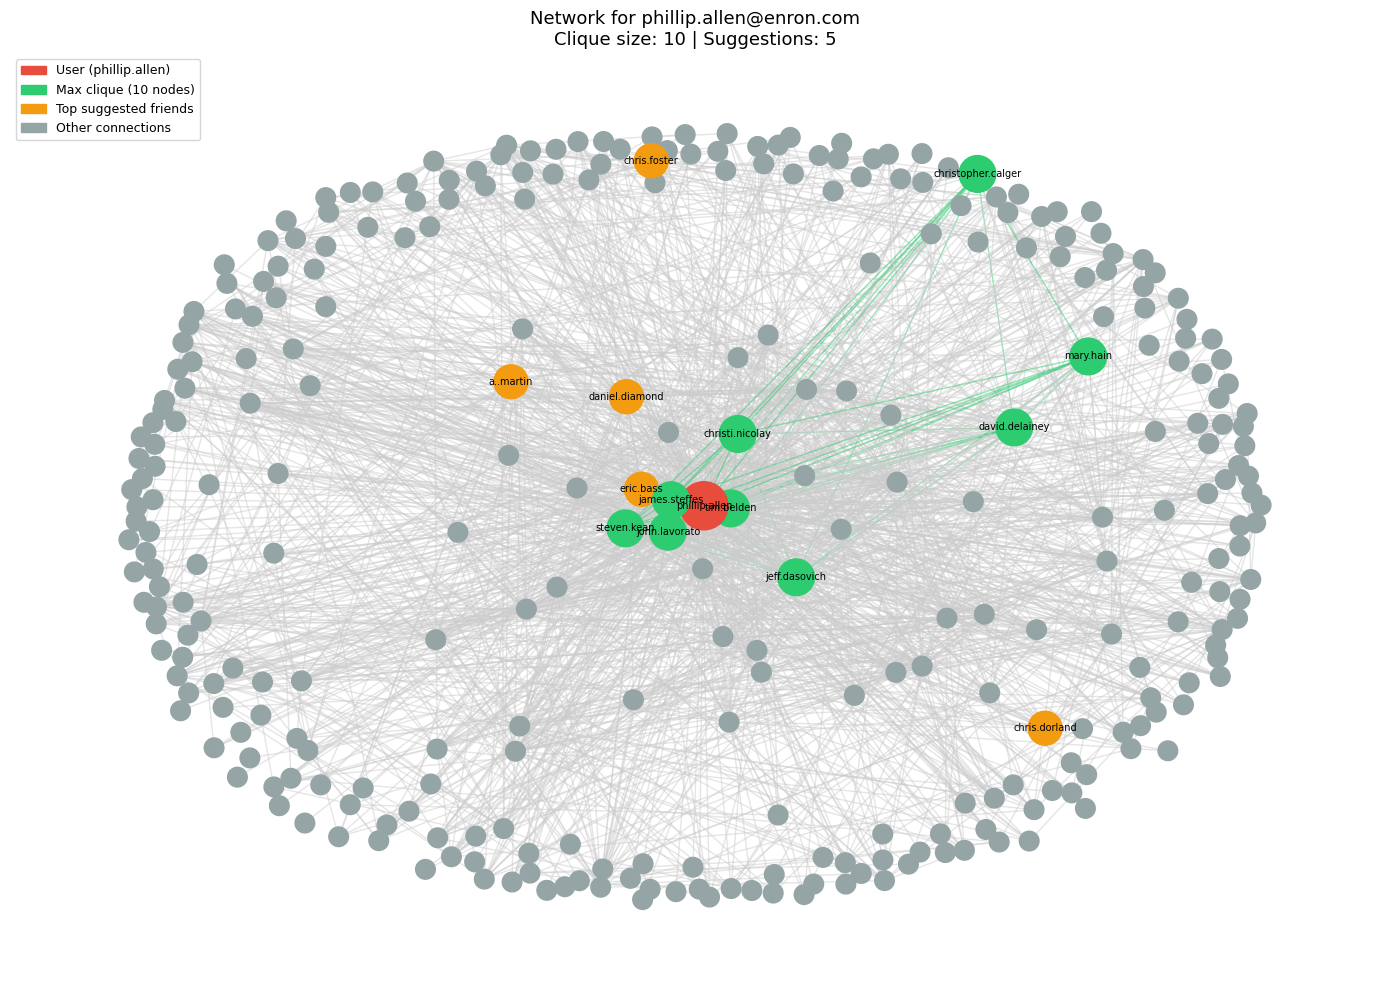


Max clique (10 members):
  mary.hain@enron.com
  steven.kean@enron.com
  tim.belden@enron.com
  david.delainey@enron.com
  phillip.allen@enron.com
  john.lavorato@enron.com
  james.steffes@enron.com
  jeff.dasovich@enron.com
  christi.nicolay@enron.com
  christopher.calger@enron.com

Top 5 users who would EXPAND the clique if added:
User                                          Connections to clique
------------------------------------------------------------
richard.sanders@enron.com                       9 / 10   ⚠️  needs 1 more connections
louise.kitchen@enron.com                        8 / 10   ⚠️  needs 2 more connections
richard.shapiro@enron.com                       8 / 10   ⚠️  needs 2 more connections
greg.whalley@enron.com                          8 / 10   ⚠️  needs 2 more connections
elizabeth.sager@enron.com                       8 / 10   ⚠️  needs 2 more connections


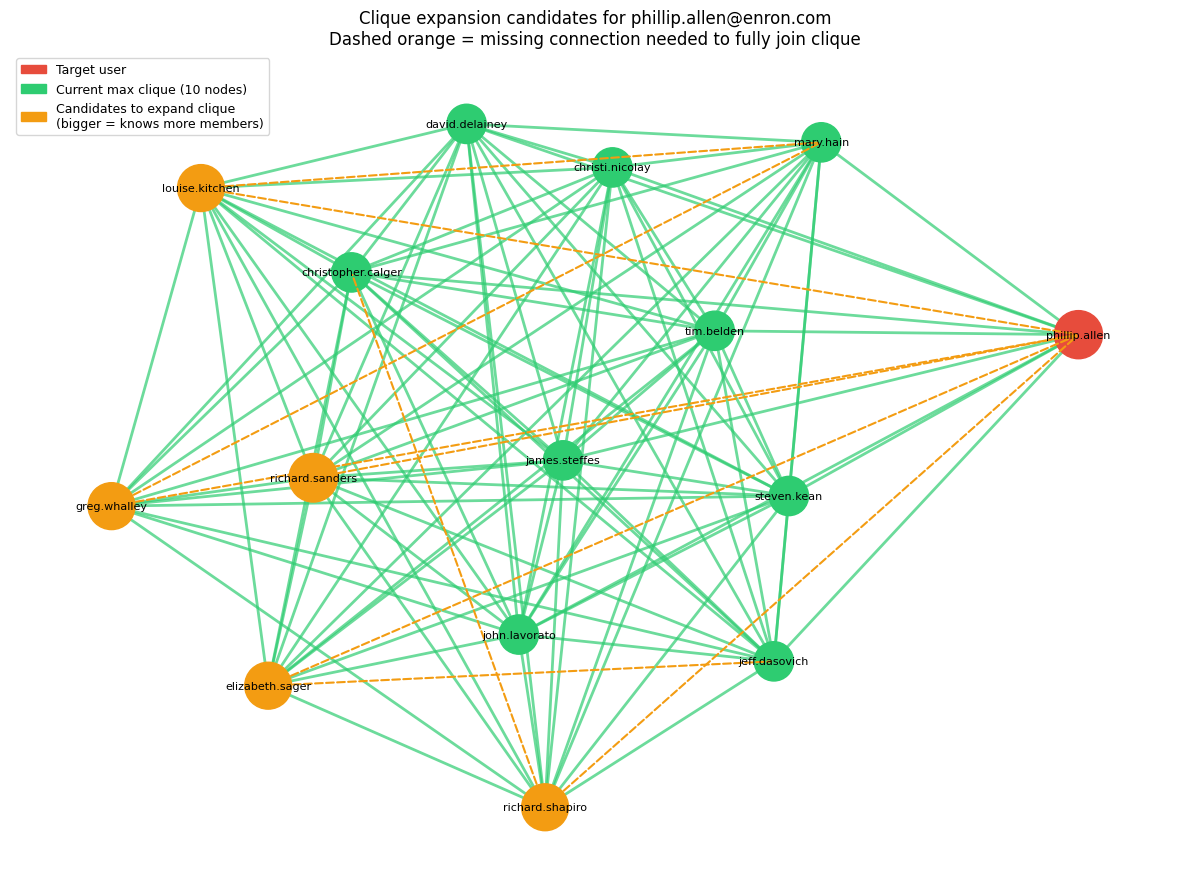

In [58]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from itertools import combinations

def visualize_user_network(user_email, figsize=(14, 10)):
    if user_email not in user2idx:
        print("User not found."); return

    uid = user2idx[user_email]
    neighbors = list(G.neighbors(uid))
    nodes_to_show = set([uid] + neighbors)
    for nb in neighbors[:20]:
        nodes_to_show.update(list(G.neighbors(nb))[:5])

    sub = G.subgraph(nodes_to_show).copy()
    cliques = [c for c in nx.find_cliques(sub) if uid in c]
    max_clique = max(cliques, key=len) if cliques else [uid]
    max_clique_set = set(max_clique)

    suggestions = []
    for node in sub.nodes():
        if node != uid and not G.has_edge(uid, node):
            mutual = len(list(nx.common_neighbors(G, uid, node)))
            score  = mutual / (G.degree(uid) + G.degree(node) - mutual + 1e-9)
            suggestions.append((node, score))
    suggestions.sort(key=lambda x: -x[1])
    top_suggested = set(n for n, _ in suggestions[:5])

    color_map = []
    size_map  = []
    for node in sub.nodes():
        if node == uid:
            color_map.append('#e74c3c'); size_map.append(1200)
        elif node in max_clique_set:
            color_map.append('#2ecc71'); size_map.append(700)
        elif node in top_suggested:
            color_map.append('#f39c12'); size_map.append(600)
        else:
            color_map.append('#95a5a6'); size_map.append(200)

    edge_colors = ['#2ecc71' if (u in max_clique_set and v in max_clique_set)
                   else '#cccccc' for u, v in sub.edges()]

    pos = nx.spring_layout(sub, seed=42, k=1.5)
    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_edges(sub, pos, edge_color=edge_colors, alpha=0.5, ax=ax)
    nx.draw_networkx_nodes(sub, pos, node_color=color_map, node_size=size_map, ax=ax)

    important = max_clique_set | top_suggested | {uid}
    labels = {n: idx2user[n].split('@')[0] for n in sub.nodes() if n in important}
    nx.draw_networkx_labels(sub, pos, labels=labels, font_size=7, ax=ax)

    legend = [
        mpatches.Patch(color='#e74c3c', label=f'User ({user_email.split("@")[0]})'),
        mpatches.Patch(color='#2ecc71', label=f'Max clique ({len(max_clique)} nodes)'),
        mpatches.Patch(color='#f39c12', label='Top suggested friends'),
        mpatches.Patch(color='#95a5a6', label='Other connections'),
    ]
    ax.legend(handles=legend, loc='upper left', fontsize=9)
    ax.set_title(f'Network for {user_email}\nClique size: {len(max_clique)} | Suggestions: {len(top_suggested)}', fontsize=13)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('user_network.png', dpi=150)
    plt.show()


def get_clique_expanders(user_email, top_k=5):
    if user_email not in user2idx:
        print("User not found."); return [], []

    uid = user2idx[user_email]
    sub = G.subgraph(list(G.neighbors(uid)) + [uid])
    cliques = [c for c in nx.find_cliques(sub) if uid in c]
    if not cliques:
        print("No cliques found."); return [], []

    max_clique = set(max(cliques, key=len))

    candidates = {}
    for node in G.nodes():
        if node not in max_clique:
            connections_to_clique = sum(1 for c in max_clique if G.has_edge(node, c))
            if connections_to_clique > 0:
                candidates[node] = connections_to_clique

    sorted_cands = sorted(candidates.items(), key=lambda x: -x[1])[:top_k]

    print(f'\nMax clique ({len(max_clique)} members):')
    for n in max_clique:
        print(f'  {idx2user[n]}')

    print(f'\nTop {top_k} users who would EXPAND the clique if added:')
    print(f"{'User':<45} {'Connections to clique':>10}")
    print('-' * 60)
    for node, conn in sorted_cands:
        can_join = '✅ can join now' if conn == len(max_clique) else f'⚠️  needs {len(max_clique)-conn} more connections'
        print(f'{idx2user[node]:<45} {conn:>3} / {len(max_clique)}   {can_join}')

    return max_clique, sorted_cands


def visualize_clique_expansion(user_email, top_k=5, figsize=(12, 9)):
    max_clique, candidates = get_clique_expanders(user_email, top_k)
    if not max_clique: return

    uid       = user2idx[user_email]
    cand_nodes = [n for n, _ in candidates]
    cand_conn  = {n: c for n, c in candidates}

    display_nodes = list(max_clique) + cand_nodes
    sub = G.subgraph(display_nodes).copy()

    missing_edges = [
        (cand, cm)
        for cand in cand_nodes
        for cm in max_clique
        if not G.has_edge(cand, cm)
    ]

    pos = nx.spring_layout(sub, seed=42, k=2.0)
    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_edges(sub, pos, edgelist=list(sub.edges()),
                           edge_color='#2ecc71', width=2, alpha=0.7, ax=ax)

    for u, v in missing_edges:
        if u in pos and v in pos:
            ax.annotate('', xy=pos[v], xytext=pos[u],
                        arrowprops=dict(arrowstyle='-', color='#f39c12',
                                        lw=1.5, linestyle='dashed'))

    colors, sizes = [], []
    for node in sub.nodes():
        if node == uid:
            colors.append('#e74c3c'); sizes.append(1200)
        elif node in max_clique:
            colors.append('#2ecc71'); sizes.append(800)
        else:
            colors.append('#f39c12'); sizes.append(500 + cand_conn.get(node, 0) * 80)

    nx.draw_networkx_nodes(sub, pos, node_color=colors, node_size=sizes, ax=ax)
    nx.draw_networkx_labels(sub, pos,
        labels={n: idx2user[n].split('@')[0] for n in sub.nodes()},
        font_size=8, ax=ax)

    legend = [
        mpatches.Patch(color='#e74c3c', label='Target user'),
        mpatches.Patch(color='#2ecc71', label=f'Current max clique ({len(max_clique)} nodes)'),
        mpatches.Patch(color='#f39c12', label='Candidates to expand clique\n(bigger = knows more members)'),
    ]
    ax.legend(handles=legend, loc='upper left', fontsize=9)
    ax.set_title(
        f'Clique expansion candidates for {user_email}\n'
        f'Dashed orange = missing connection needed to fully join clique',
        fontsize=12
    )
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('clique_expansion.png', dpi=150)
    plt.show()


# ── Run ───────────────────────────────────────────────────────────────
user = 'phillip.allen@enron.com'
visualize_user_network(user)
visualize_clique_expansion(user, top_k=5)



In [43]:
# Find the most connected users to pick a good demo
top_users = sorted(user2idx.keys(), key=lambda u: G.degree(user2idx[u]), reverse=True)[:10]
for u in top_users:
    uid = user2idx[u]
    cliques = [c for c in nx.find_cliques(G.subgraph(list(G.neighbors(uid)) + [uid])) if uid in c]
    max_clique = max(cliques, key=len) if cliques else []
    print(f'{u:45s}  degree: {G.degree(uid):4d}  max clique: {len(max_clique)}')

klay@enron.com                                 degree: 1294  max clique: 4
tana.jones@enron.com                           degree:  917  max clique: 13
sara.shackleton@enron.com                      degree:  915  max clique: 13
jeff.dasovich@enron.com                        degree:  889  max clique: 13
vince.kaminski@enron.com                       degree:  834  max clique: 11
kenneth.lay@enron.com                          degree:  708  max clique: 12
gerald.nemec@enron.com                         degree:  693  max clique: 12
sally.beck@enron.com                           degree:  686  max clique: 12
jeff.skilling@enron.com                        degree:  684  max clique: 11
louise.kitchen@enron.com                       degree:  680  max clique: 12


In [48]:

# spectral upgrade testff